In [ ]:
import os, sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from src.constants import DATA_DIR, DATASET_NAME
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


In [19]:
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR/DATA_DIR/DATASET_NAME

try:
    df = pd.read_csv(DATA_PATH)
    print("Data has been loaded!")
    print(df.shape)
except:
    print("Data Failed to load.. Please Check Data Path")


Data has been loaded!
(15420, 33)


In [82]:
df.head()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [19]:
def data_scan(df):
    '''
    Detailed summary of the dataframe including missing values, 
    unique counts, and data types.
    '''
    info = pd.DataFrame(df.dtypes, columns=['DataType'])
    info['Missing'] = df.isnull().sum()
    info['Missing (%)'] = (df.isnull().sum()/len(df)) * 100
    info['Unique Values'] = df.nunique()
    
    return info.sort_values(by='Missing (%)', ascending=False)

data_scan(df)


,DataType,Missing,Missing (%),Unique Values
Month,str,0,0.0,12
RepNumber,int64,0,0.0,16
Year,int64,0,0.0,3
NumberOfCars,str,0,0.0,5
AddressChange_Claim,str,0,0.0,5
NumberOfSuppliments,str,0,0.0,4
AgentType,str,0,0.0,2
WitnessPresent,str,0,0.0,2
PoliceReportFiled,str,0,0.0,2
AgeOfPolicyHolder,str,0,0.0,9


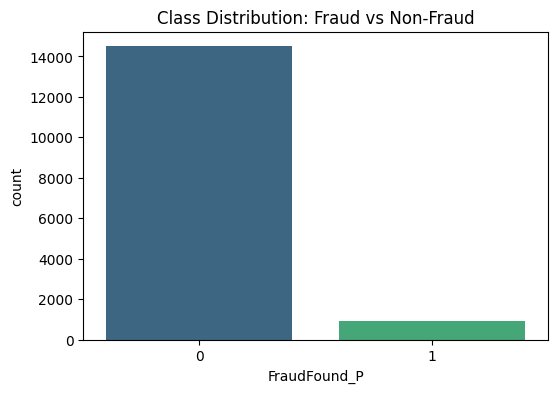

FraudFound_P
0    94.014267
1     5.985733
Name: proportion, dtype: float64


In [28]:
target_col = 'FraudFound_P'

plt.figure(figsize=(6,4))
sns.countplot(x=df[target_col], palette='viridis')
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.show()

print(df[target_col].value_counts(normalize=True) * 100)


#### Fraud data is only 5% and Non-Fraud Data is 95% due to this model can be bias, we need to do oversampling.

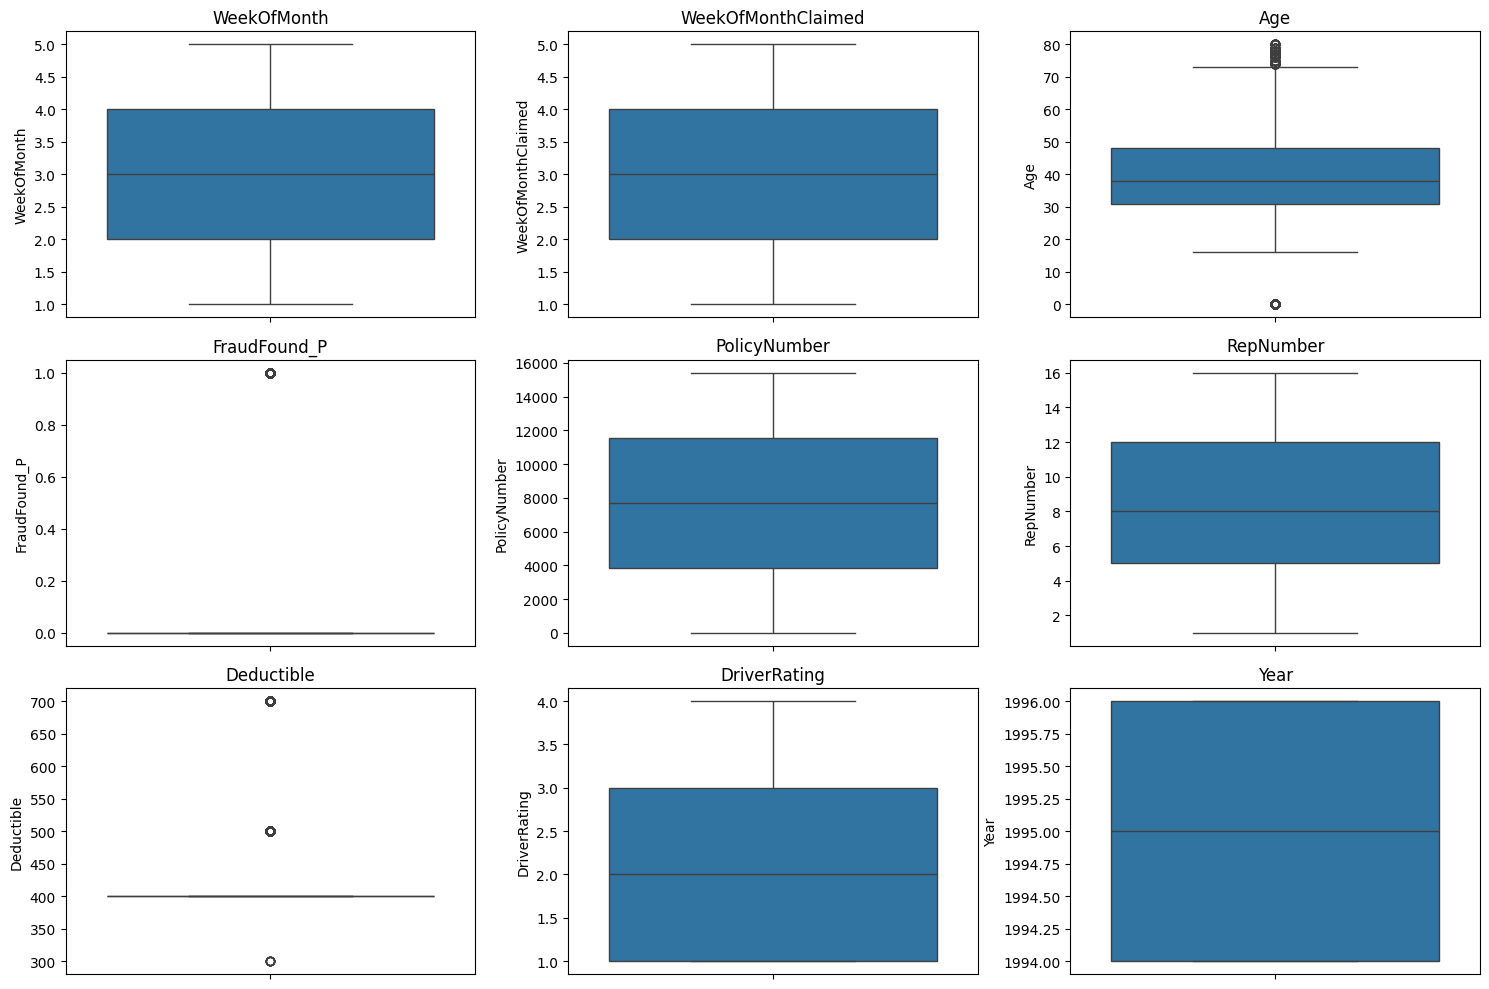

In [30]:
# Numerical Features and Outliers

num_cols = df.select_dtypes(include=['int64','float64']).columns

# Boxplot
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


#### There's an outlier in age where age is 0

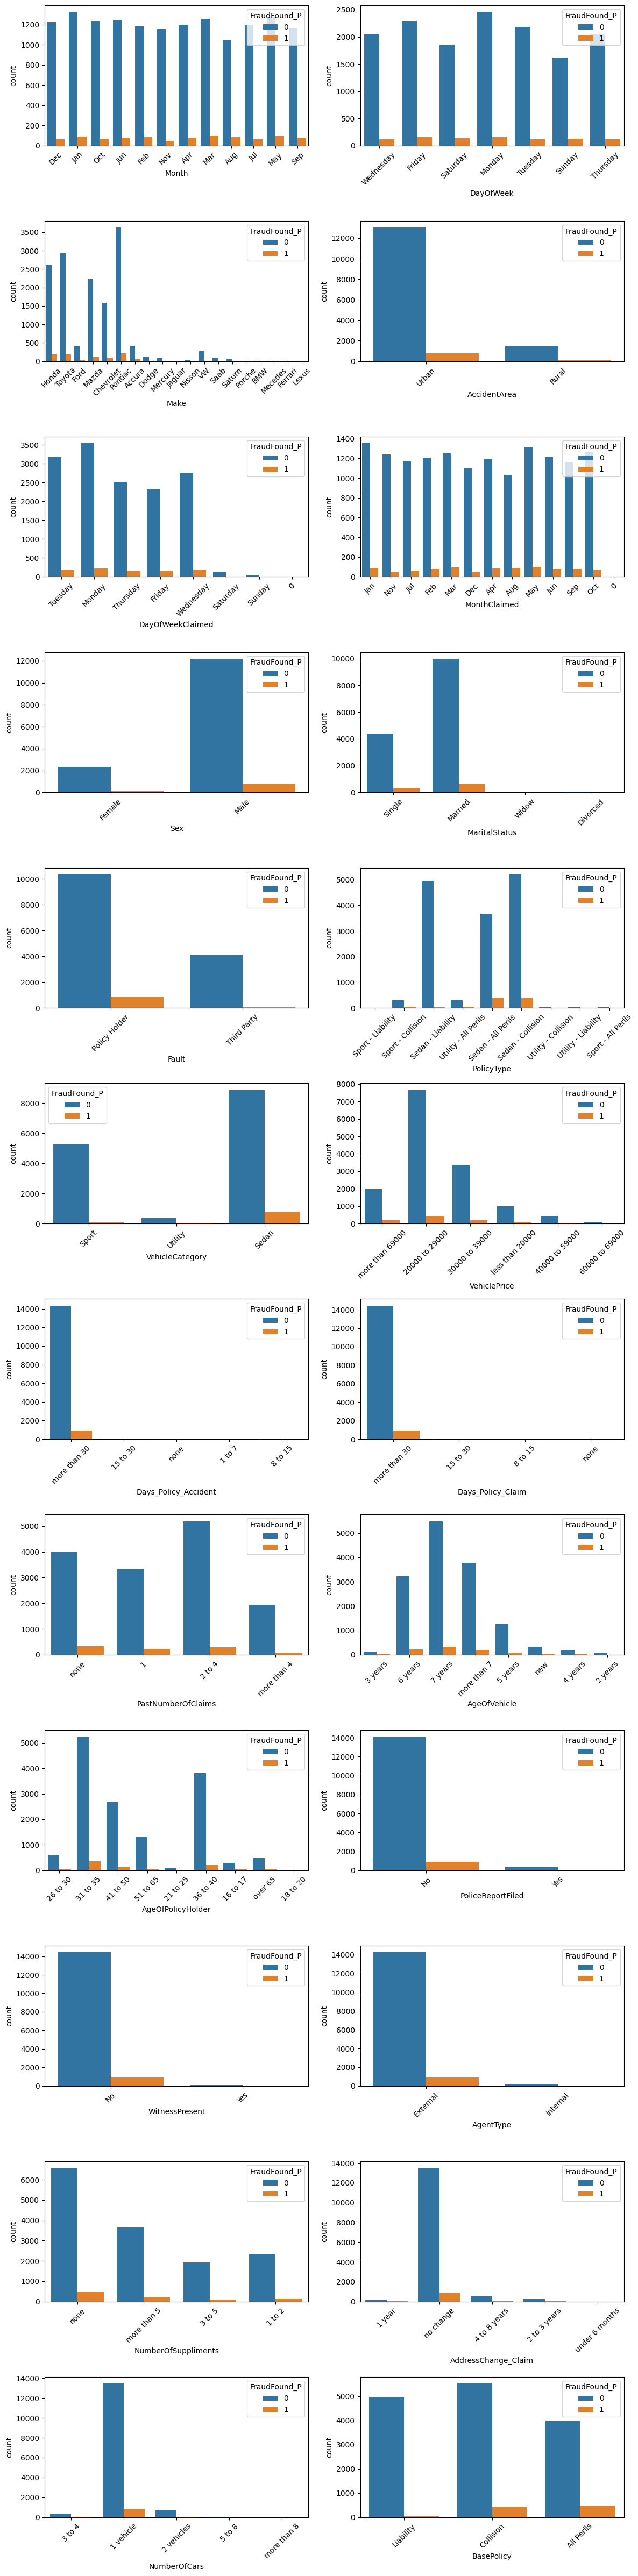

In [87]:
cat_cols = df.select_dtypes(include=['str','object']).columns
n_cols = len(cat_cols)

rows = (n_cols // 2) + (n_cols % 2)

plt.figure(figsize=(12, 4 * rows))

for i,col in enumerate(cat_cols):
    plt.subplot(rows,2,i+1)
    sns.countplot(data=df, x=col, hue=target_col)
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()


#### DayOfWeekClaimed and MonthClaimed contains 0. we will remove that row

<Axes: >

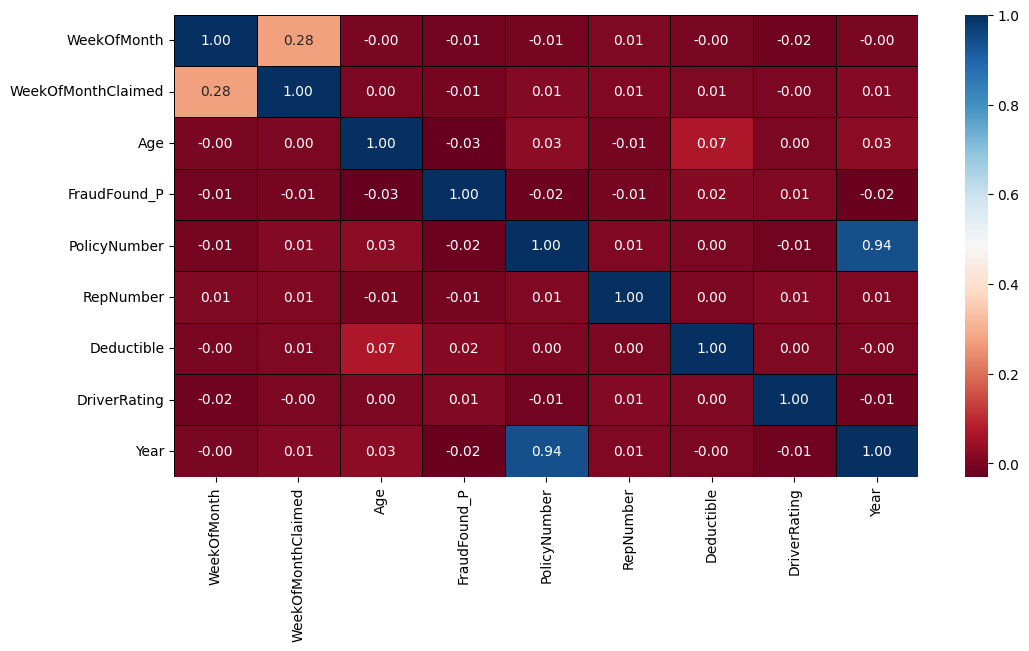

In [56]:
plt.figure(figsize=(12,6))
sns.heatmap(df[num_cols].corr(), cmap='RdBu', linewidths=0.5, linecolor='black', annot=True, fmt='.2f')


#### PolicyNumber Column is of no use and it is highly correlated with Year

## Report

#### 1. Data Cleaning
####    - Remove those rows which contains 0 in DayOfWeekClaimed and MonthClaimed Columns 
####    - Fix value 0 in age that's an outlier we need to impute that
####    - Drop PolicyNumber Column: Unnecessary and Highly Correlated with Year

#### 2. Fix Data Imbalance
####    - Non Fraud Data is Approx. 95% and Fraud Data is Approx. 5% to not to Get Biased Model